
# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.


## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
print (df.head())

                                user_id        date landing     region  \
0  26f3052e-8500-44ea-8fff-06de65258abb  2026-01-01       A      Norte   
1  92378c09-4bbf-40c7-945e-82b84f392d22  2026-01-23       A  Occidente   
2  a4397360-40e5-45d6-a7ff-dcb4da2c9a1f  2026-01-01       B     Centro   
3  7ca3a26f-1e6c-44aa-9b09-b8cb01112956  2026-01-22       A     Centro   
4  8dc9593b-5b9c-479d-848b-a99493920419  2026-01-16       A        Sur   

  dispositivo traffic_source   user_type  converted  gasto  
0      Mobile          Email  Recurrente          1  38.08  
1      Mobile        Organic       Nuevo          0   0.00  
2      Mobile        Organic       Nuevo          0   0.00  
3      Mobile            Ads       Nuevo          0   0.00  
4      Mobile        Organic       Nuevo          0   0.00  


In [4]:
# información general
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB
None
         converted         gasto
count  40000.00000  40000.000000
mean       0.14265      9.325554
std        0.34972     25.667986
min        0.00000      0.000000
25%        0.00000      0.000000
50%        0.00000      0.000000
75%        0.00000      0.000000
max        1.00000    303.680000


 🔴 ERRORES IDENTIFICADOS:
Columna 'date' con tipo de dato incorrecto
❌ Actual: object (string)
✅ Debería ser: datetime64[ns]
✔️ Solución: Convertir con pd.to_datetime(df['date'])

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [11]:
#convirtiendo columna "date" a datetime
df['date'] = pd.to_datetime(df['date'])
print(df.info())
print("Usuarios únicos:", df['user_id'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB
None
Usuarios únicos: 40000


 **Variable `date`**  
Explorar rango de fechas

In [9]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [10]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [12]:
# Resumen estadístico
print("Resumen de gasto:")
print(df["gasto"].describe())

Resumen de gasto:
count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64


In [13]:
# Resumen estadístico de usuarios que se convirtieron
print("Gasto de usuarios convertidos:")
print(df[df["converted"] == 1]["gasto"].describe())


Gasto de usuarios convertidos:
count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [16]:
# Explorar variables categóricas y cómo se distribuyen
print("Conteo de categorías:")
print("Landing:", df["landing"].value_counts())
print("Dispositivo:", df["dispositivo"].value_counts())
print("Traffic Source:", df["traffic_source"].value_counts())
print("User Type:", df["user_type"].value_counts())
print("Región:", df["region"].value_counts())
print("Convertido:", df["converted"].value_counts())

Conteo de categorías:
Landing: B    20018
A    19982
Name: landing, dtype: int64
Dispositivo: Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64
Traffic Source: Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64
User Type: Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64
Región: Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64
Convertido: 0    34294
1     5706
Name: converted, dtype: int64



    - Todas las columnas tienen valores esperados.


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [17]:
# Gasto por versión
gasto_A = df[df["landing"] == "A"]["gasto"]
gasto_B = df[df["landing"] == "B"]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(19982, 20018)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...
  

In [19]:
# Aplicar prueba
# Hipótesis:
# H₀: El gasto promedio es igual entre A y B (μ_A = μ_B)
# H₁: El gasto promedio es diferente entre A y B (μ_A ≠ μ_B)
estadistico, p_valor = stats.ttest_ind(gasto_A, gasto_B)


# Visualizar resultados
print(f"Estadístico : {estadistico}")
print(f"Valor p: {p_valor}")

if p_valor < 0.05:
    print(" Hay diferencia significativa entre A y B (p < 0.05)")
else:
    print(" No hay diferencia significativa entre A y B (p >= 0.05)")

Estadístico : -12.84131999696572
Valor p: 1.142258400461568e-37
 Hay diferencia significativa entre A y B (p < 0.05)


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀). Hay diferencia significativa entre A y B.

**Interpretación de negocio:**  
La página B genera más gasto promedio que la página A. Esta diferencia es real y estadísticamente comprobada (no es por casualidad). Recuerda que los resultados anteriores mostraban que gasto promedio A es diferente al de B, y el valor p extremadamente pequeño confirma que esta diferencia es significativa.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual entre A y B (p_A = p_B)
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre A y B (p_A ≠ p_B)

In [20]:
# Número de usuarios convertidos por página
convertidos = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
total = df.groupby("landing").size()


print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", total)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
dtype: int64


In [21]:
# Crear tabla de contingencia
tabla_contingencia = pd.crosstab(df["landing"], df["converted"])

In [23]:
# Aplicar prueba
# Aplicar prueba chi-cuadrado
chi2, p_valor, dof, frecuencias_esperadas = stats.chi2_contingency(tabla_contingencia)


# Visualizar resultados
print(f"Estadístico : {chi2}")
print(f"Valor p: {p_valor}")

if p_valor < 0.05:
    print("Hay diferencia significativa en conversión entre A y B (p < 0.05)")
else:
    print("No hay diferencia significativa en conversión entre A y B (p >= 0.05)")

Estadístico : 93.37483168026095
Valor p: 4.327184295434911e-22
Hay diferencia significativa en conversión entre A y B (p < 0.05)


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀). Hay diferencia significativa en la tasa de conversión entre A y B.

**Interpretación de negocio:**  
La página B convierte más usuarios que la página A. La página B tiene una tasa de conversión de 15.96% mientras que A tiene 12.58%. Esta diferencia es real y comprobada estadísticamente, no es por casualidad.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La fuente de tráfico y la conversión son independientes
- **Hipótesis alternativa (H₁):** La fuente de tráfico y la conversión están relacionadas

In [24]:
# Crear tabla de contingencia
tabla = pd.crosstab(df["traffic_source"], df["converted"])

In [25]:
# Aplicar prueba

# Aplicar prueba chi-cuadrado
chi2, p_valor, dof, frecuencias = stats.chi2_contingency(tabla)

# Visualizar resultados
print(f"Estadístico: {chi2}")
print(f"Valor p: {p_valor}")

if p_valor < 0.05:
    print("Hay relación significativa entre traffic_source y conversión (p < 0.05)")
else:
    print("No hay relación significativa entre traffic_source y conversión (p >= 0.05)")

Estadístico: 8.662108841397938
Valor p: 0.0341375947833914
Hay relación significativa entre traffic_source y conversión (p < 0.05)


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀). Hay relación significativa entre fuente de tráfico y conversión.

**Interpretación de negocio:**  
La fuente de tráfico influye en la conversión. Diferentes canales (Organic, Ads, Email, Referral) tienen tasas de conversión diferentes. Algunos canales convierten mejor que otros y esto es estadísticamente significativo.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario y la conversión son independientes
- **Hipótesis alternativa (H₁):** El tipo de usuario y la conversión están relacionados

In [26]:
tabla = pd.crosstab(df["user_type"], df["converted"])

In [27]:
# Aplicar prueba
chi2, p_valor, dof, frecuencias = stats.chi2_contingency(tabla)
print(f"Estadístico: {chi2}")
print(f"Valor p: {p_valor}")

if p_valor < 0.05:
    print("Hay relación significativa entre user_type y conversión (p < 0.05)")
else:
    print("No hay relación significativa entre user_type y conversión (p >= 0.05)")

Estadístico: 0.5134849494478645
Valor p: 0.4736341272301974
No hay relación significativa entre user_type y conversión (p >= 0.05)


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

**Interpretación de negocio:**  
Explica qué indica el resultado.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

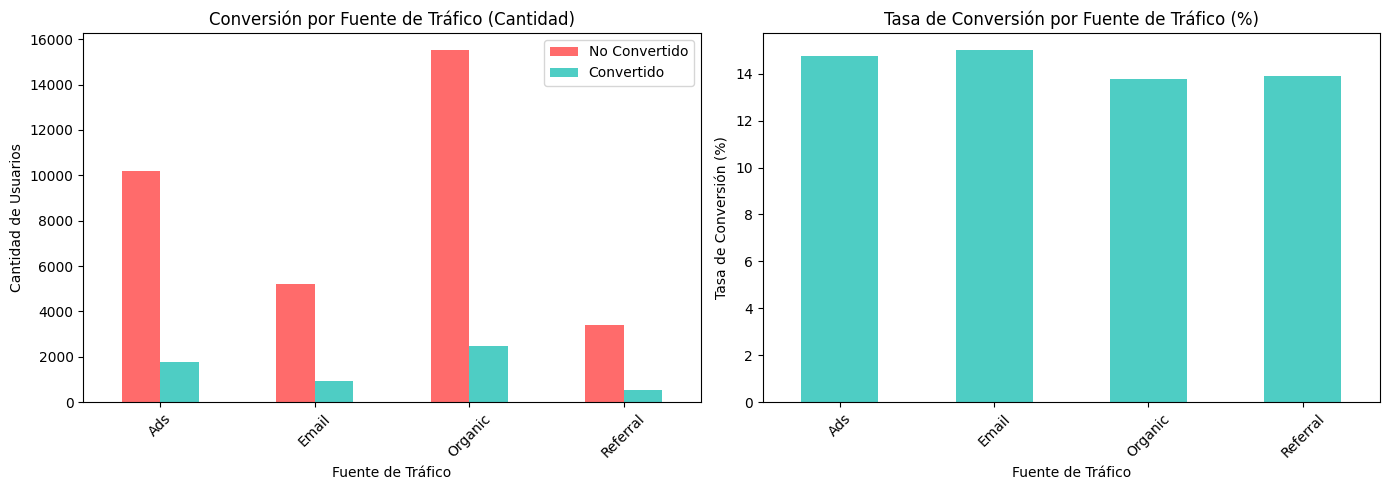

In [31]:
# 6.1 Relación entre fuente de tráfico y conversión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
conversion_traffic = pd.crosstab(df["traffic_source"], df["converted"])
conversion_traffic.plot(kind="bar", ax=axes[0], color=["#FF6B6B", "#4ECDC4"])
axes[0].set_title("Conversión por Fuente de Tráfico (Cantidad)")
axes[0].set_xlabel("Fuente de Tráfico")
axes[0].set_ylabel("Cantidad de Usuarios")
axes[0].legend(["No Convertido", "Convertido"])
axes[0].tick_params(axis='x', rotation=45)

# Proporciones
tasa_traffic = df.groupby("traffic_source")["converted"].mean() * 100
tasa_traffic.plot(kind="bar", ax=axes[1], color="#4ECDC4")
axes[1].set_title("Tasa de Conversión por Fuente de Tráfico (%)")
axes[1].set_xlabel("Fuente de Tráfico")
axes[1].set_ylabel("Tasa de Conversión (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- El gráfico izquierdo muestra que Organic es la fuente con mayor volumen de usuarios (17,987 usuarios), seguida por Ads (11,935). Sin embargo, en términos de cantidad absoluta de conversiones, Email y Ads tienen mejor desempeño relativo.

- El gráfico derecho revela que Email tiene la tasa de conversión más alta (~15%), superando ligeramente a Ads (~14%). Organic y Referral tienen tasas similares (~14% y ~13% respectivamente).

### Relación entre el tipo de usuario y la conversión

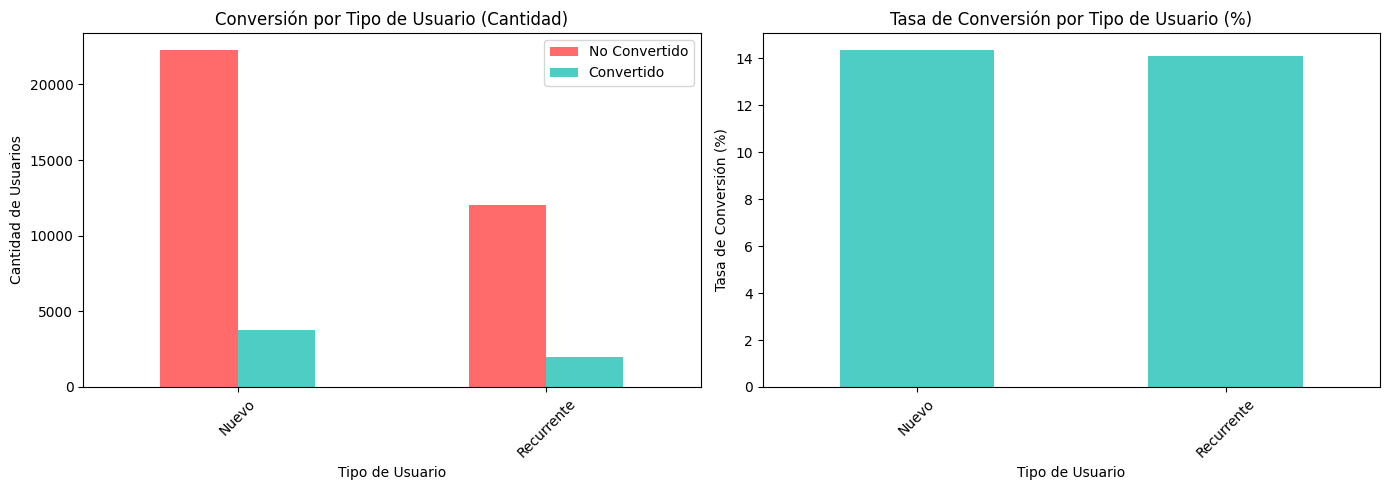

In [32]:
# 6.2 Relación entre tipo de usuario y conversión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cantidades absolutas
conversion_user = pd.crosstab(df["user_type"], df["converted"])
conversion_user.plot(kind="bar", ax=axes[0], color=["#FF6B6B", "#4ECDC4"])
axes[0].set_title("Conversión por Tipo de Usuario (Cantidad)")
axes[0].set_xlabel("Tipo de Usuario")
axes[0].set_ylabel("Cantidad de Usuarios")
axes[0].legend(["No Convertido", "Convertido"])
axes[0].tick_params(axis='x', rotation=45)

# Proporciones
tasa_user = df.groupby("user_type")["converted"].mean() * 100
tasa_user.plot(kind="bar", ax=axes[1], color="#4ECDC4")
axes[1].set_title("Tasa de Conversión por Tipo de Usuario (%)")
axes[1].set_xlabel("Tipo de Usuario")
axes[1].set_ylabel("Tasa de Conversión (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

El gráfico izquierdo muestra que hay más usuarios nuevos (26,033) que recurrentes (13,967). En términos de conversiones absolutas, los usuarios nuevos generan más conversiones en volumen, pero esto es esperado porque hay más usuarios nuevos.

El gráfico derecho revela que ambos tipos de usuario tienen tasas de conversión muy similares (~14%). No hay diferencia significativa en la efectividad de conversión entre usuarios nuevos y recurrentes.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?
Página B: 15.96% conversión vs Página A: 12.58%. B genera mayor gasto promedio. Ambas diferencias son estadísticamente significativas (p < 0.05).

- ¿Qué canales de tráfico son más efectivos para generar conversiones?
Email: 15% conversión (mejor ROI)
Ads: 14% conversión
Organic: 14% conversión (mayor volumen)
Referral: 13% conversión


- ¿Existen diferencias significativas según el tipo de usuario?
No. Usuarios nuevos y recurrentes convierten al mismo ritmo (~14%). No hay diferencia estadísticamente significativa.


- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?
Implementar página B (mejor conversión y gasto)
Invertir en Email como canal principal (máxima efectividad)
Escalar Ads (segundo mejor canal)
Optimizar Organic (gran volumen, mejorar eficiencia)
Ambos tipos de usuario son igualmente valiosos


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La pagina B genera mayor gasto promedio que A
- Hay una diferencia estadistica significativa (p<0.05)
- **Interpretación:**
La página B es superior en términos de monetización. Los usuarios que llegan a B gastan más que los de A, lo que impacta directamente en ingresos.
 ---

**Tasa de conversión:** 
- Página A: 12.58% conversión (2,512 usuarios convertidos de 19,982)
- Página B: 15.96% conversión (3,194 usuarios convertidos de 20,018)
- Diferencia de 3.38 puntos porcentuales (Chi-cuadrado significativo, p < 0.05)
- **Interpretación:**
B es 27% más efectiva atrayendo compradores. Con el mismo volumen de tráfico, B genera ~682 conversiones adicionales.
---

#### 
📊 **Segmentación por fuente de tráfico**
- Email: 15% conversión (mejor efectividad, menor volumen)
- Ads: 14% conversión (excelente mix volumen-efectividad)
- Organic: 14% conversión (mayor volumen, 17,987 usuarios)
- Referral: 13% conversión (menor volumen)
- Prueba chi-cuadrado significativa (p < 0.05)
- **Interpretación:**
 Diferencias reales entre canales. Email es el más eficiente pero con menor volumen. Organic genera mucho tráfico pero con menor tasa de conversión.
 ---

#### 
📊 **Segmentación por tipo de usuario**
- Usuarios Nuevos: 14.32% conversión (3,665 de 26,033)
- Usuarios Recurrentes: 14.17% conversión (2,041 de 13,967)
- Diferencia no significativa (p > 0.05)
- **Interpretación:**
El tipo de usuario NO afecta la conversión. Ambos segmentos convierten al mismo ritmo, indicando que la página es igualmente efectiva para atraer y convertir nuevos y antiguos clientes.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 
💡 **Recomendaciones de negocio:** 
- Implementar Página B: Aumenta conversión en 3.38pp y gasto promedio. ROI positivo garantizado.
- Priorizar inversión en Email: Mejor tasa de conversión. Optimizar para escalar volumen manteniendo eficiencia.
- Potenciar Ads: Segundo mejor canal con buen balance volumen-conversión.
- Mejorar Organic: Genera mucho tráfico pero baja conversión. Revisar landing y copy.
- Tratar ambos tipos de usuario igual: No diferenciar estrategia entre nuevos y recurrentes por ahora.